# Step 6 — Build a Calibrated SimPy Environment

This notebook completes **Step 6 only**.

Goal: build a simulation environment that uses calibrated transition/duration behavior and supports an action hook for routing/priority decisions.

## What we do in this step (simple view)

1. Load calibration artifacts from Steps 2–5.
2. Build transition and duration sampling models.
3. Add a deterministic action mask and a simple policy hook.
4. Simulate case arrivals and event progression with SimPy.
5. Save trace/episode outputs and run Step 6 checks.

In [19]:
%pip install simpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
import json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import simpy
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('./output')

FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
FEATURES_CSV = OUTPUT_DIR / 'case_step_features.csv'
TRANSITION_STATS_PATH = OUTPUT_DIR / 'transition_stats.csv'
DURATION_STATS_PATH = OUTPUT_DIR / 'duration_stats.csv'
SIM_CALIBRATION_PATH = OUTPUT_DIR / 'sim_calibration.json'
VALID_ACTION_PATH = OUTPUT_DIR / 'valid_action_space.csv'
REWARD_TUNED_PATH = OUTPUT_DIR / 'reward_params_kpi_tuned.json'

SIM_TRACE_PATH = OUTPUT_DIR / 'sim_trace_table.csv'
SIM_EPISODE_PATH = OUTPUT_DIR / 'sim_episode_summary.csv'
SIM_RUN_SUMMARY_PATH = OUTPUT_DIR / 'sim_run_summary.csv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR.resolve())

Output dir: /mnt/HDD/Code/Python/bwa/output


In [21]:
# Load case-step features from Step 2
if not FEATURES_PARQUET.exists():
    print('Error: previous notebook should be run first (Step 2 missing case_step_features.parquet).')
    raise SystemExit(1)

features_df = pd.read_parquet(FEATURES_PARQUET)
features_loaded_from = FEATURES_PARQUET

# Load calibration stats from Step 3
if not TRANSITION_STATS_PATH.exists() or not DURATION_STATS_PATH.exists() or not SIM_CALIBRATION_PATH.exists():
    print('Error: previous notebook should be run first (Step 3 artifacts missing).')
    raise SystemExit(1)

transition_stats = pd.read_csv(TRANSITION_STATS_PATH)
duration_stats = pd.read_csv(DURATION_STATS_PATH)
with open(SIM_CALIBRATION_PATH, 'r') as f:
    sim_calibration = json.load(f)

# Load action dictionary summary from Step 4 (required)
if not VALID_ACTION_PATH.exists():
    print('Error: previous notebook should be run first (Step 4 missing valid_action_space.csv).')
    raise SystemExit(1)
valid_action_space_df = pd.read_csv(VALID_ACTION_PATH)

# Load KPI-tuned reward parameters from Step 5.5 (required)
if not REWARD_TUNED_PATH.exists():
    print('Error: previous notebook should be run first (Step 5.5 missing reward_params_kpi_tuned.json).')
    raise SystemExit(1)
with open(REWARD_TUNED_PATH, 'r') as f:
    payload = json.load(f)
tuned = payload.get('tuned_params', {})
reward_params_tuned = {}
for key in ['alpha', 'beta', 'delta', 'gamma']:
    if key not in tuned or pd.isna(tuned[key]):
        print(f'Error: previous notebook should be run first (Step 5.5 missing tuned param: {key}).')
        raise SystemExit(1)
    reward_params_tuned[key] = float(tuned[key])

features_df['timestamp'] = pd.to_datetime(features_df['timestamp'], utc=True, errors='coerce')
features_df = features_df.sort_values(['municipality', 'case_id', 'step_index']).reset_index(drop=True)

print(f'Features loaded from: {features_loaded_from.name}, rows={len(features_df):,}')
print(f'Transitions rows: {len(transition_stats):,}')
print(f'Duration rows: {len(duration_stats):,}')
print('Action-space rows:', len(valid_action_space_df))
print('Calibration keys:', list(sim_calibration.keys()))
print('Using KPI-tuned reward params:', reward_params_tuned)

Features loaded from: case_step_features.parquet, rows=262,628
Transitions rows: 28,986
Duration rows: 1,783
Action-space rows: 15
Calibration keys: ['notes', 'transition_stats_path', 'duration_stats_path', 'branch_probability_method', 'branch_confidence_min', 'branch_probabilities', 'arrival_proxy_by_municipality']
Using KPI-tuned reward params: {'alpha': 0.021521, 'beta': 0.75, 'delta': 6.25, 'gamma': 12.767392}


## 6.1 Build simulation models from calibration tables

The helper functions below convert CSV calibration artifacts into fast lookup structures for simulation.

In [22]:
if not valid_action_space_df.empty and {'action_id', 'action_name'}.issubset(valid_action_space_df.columns):
    action_table = valid_action_space_df[['action_id', 'action_name']].copy()
    action_table['action_id'] = pd.to_numeric(action_table['action_id'], errors='coerce')
    action_table = action_table.dropna(subset=['action_id']).sort_values('action_id')
    ACTIONS = action_table['action_name'].astype(str).tolist()
else:
    print('Error: previous notebook should be run first (Step 4 action CSV is invalid).')
    raise SystemExit(1)

if 'assign_to_primary_team' in ACTIONS:
    DEFAULT_ACTION = 'assign_to_primary_team'
elif 'continue_normal_path' in ACTIONS:
    DEFAULT_ACTION = 'continue_normal_path'
else:
    DEFAULT_ACTION = ACTIONS[0]

def build_transition_models(transition_df: pd.DataFrame):
    """Create transition lookup models and allowed-edge sets per municipality."""
    transition_df = transition_df.copy()
    transition_df['municipality_int'] = pd.to_numeric(transition_df['municipality'], errors='coerce').astype('Int64')

    by_municipality = defaultdict(lambda: defaultdict(list))
    global_model = defaultdict(list)
    allowed_edges_by_m = defaultdict(set)

    for _, row in transition_df.iterrows():
        src = str(row['activity'])
        tgt = str(row['next_activity'])
        prob = float(row['transition_prob'])
        m_raw = row['municipality_int']
        m = None if pd.isna(m_raw) else int(m_raw)

        if m is None:
            global_model[src].append((tgt, prob))
        else:
            by_municipality[m][src].append((tgt, prob))
            allowed_edges_by_m[m].add((src, tgt))

    def normalize_model(model_dict):
        out = {}
        for src, pairs in model_dict.items():
            total = sum(p for _, p in pairs)
            if total <= 0:
                continue
            out[src] = [(tgt, p / total) for tgt, p in pairs]
        return out

    by_municipality = {m: normalize_model(model) for m, model in by_municipality.items()}
    global_model = normalize_model(global_model)

    global_edges = {(src, tgt) for src, pairs in global_model.items() for tgt, _ in pairs}
    for m in by_municipality.keys():
        allowed_edges_by_m[m] = set(allowed_edges_by_m[m]) | global_edges

    return by_municipality, global_model, allowed_edges_by_m

def build_duration_models(duration_df: pd.DataFrame):
    """Create duration lookup models with municipality-specific and global fallback stats."""
    duration_df = duration_df.copy()
    duration_df['municipality_int'] = pd.to_numeric(duration_df['municipality'], errors='coerce').astype('Int64')

    by_municipality = defaultdict(dict)
    global_model = {}

    for _, row in duration_df.iterrows():
        m_raw = row['municipality_int']
        m = None if pd.isna(m_raw) else int(m_raw)
        activity = str(row['activity'])
        stats = {
            'obs_count': float(row.get('obs_count', 0.0)),
            'median': float(row.get('duration_median_hours', np.nan)),
            'q25': float(row.get('duration_q25_hours', np.nan)),
            'q75': float(row.get('duration_q75_hours', np.nan)),
            'mean': float(row.get('duration_mean_hours', np.nan)),
            'std': float(row.get('duration_std_hours', np.nan)),
            'max': float(row.get('duration_max_hours', np.nan)),
        }
        if m is None:
            global_model[activity] = stats
        else:
            by_municipality[m][activity] = stats

    return dict(by_municipality), global_model

def build_start_activity_models(features: pd.DataFrame):
    """Estimate start activity, expected trace length, and completion rate from real cases."""
    ordered = features.sort_values(['municipality', 'case_id', 'step_index'])

    first_events = (
        ordered.groupby(['municipality', 'case_id'], as_index=False)
        .first()[['municipality', 'activity']]
    )

    start_dist_by_m = {}
    for m, grp in first_events.groupby('municipality'):
        counts = grp['activity'].value_counts()
        probs = (counts / counts.sum()).to_dict()
        start_dist_by_m[int(m)] = probs

    avg_trace_len_by_m = (
        ordered.groupby(['municipality', 'case_id'])['step_index'].max().add(1)
        .groupby('municipality').mean().to_dict()
    )

    case_completion = (
        ordered.groupby(['municipality', 'case_id'])['case_completed']
        .max()
        .astype(float)
        .groupby('municipality')
        .mean()
        .to_dict()
    )

    completion_rate_by_m = {
        int(k): float(np.clip(v, 0.05, 0.98))
        for k, v in case_completion.items()
        if pd.notna(v)
    }

    avg_trace_len_by_m = {int(k): float(v) for k, v in avg_trace_len_by_m.items()}
    return start_dist_by_m, avg_trace_len_by_m, completion_rate_by_m

In [23]:
transition_model_by_m, transition_model_global, allowed_edges_by_m = build_transition_models(transition_stats)
duration_model_by_m, duration_model_global = build_duration_models(duration_stats)
start_activity_dist_by_m, avg_trace_len_by_m, completion_rate_by_m = build_start_activity_models(features_df)

municipality_case_volume = (
    features_df[['municipality', 'case_id']].drop_duplicates().groupby('municipality').size()
 )
volume_q75 = float(municipality_case_volume.quantile(0.75)) if len(municipality_case_volume) else 0.0
high_volume_municipalities = {int(m) for m, c in municipality_case_volume.items() if float(c) >= volume_q75}

arrival_proxy = pd.DataFrame(sim_calibration.get('arrival_proxy_by_municipality', []))
arrival_mean_hours_by_m = {
    int(row['municipality']): float(row['interarrival_mean_hours'])
    for _, row in arrival_proxy.iterrows()
    if pd.notna(row.get('interarrival_mean_hours'))
}

print('Transition models loaded for municipalities:', sorted(transition_model_by_m.keys()))
print('Duration models loaded for municipalities   :', sorted(duration_model_by_m.keys()))
print('Start-activity models loaded for municipalities:', sorted(start_activity_dist_by_m.keys()))
print('Arrival mean-hours keys:', sorted(arrival_mean_hours_by_m.keys()))
print('Completion-rate keys:', sorted(completion_rate_by_m.keys()))
print('Action count loaded from Step 4 CSV:', len(ACTIONS))
print('Default action:', DEFAULT_ACTION)

Transition models loaded for municipalities: [1, 2, 3, 4, 5]
Duration models loaded for municipalities   : [1, 2, 3, 4, 5]
Start-activity models loaded for municipalities: [1, 2, 3, 4, 5]
Arrival mean-hours keys: [1, 2, 3, 4, 5]
Completion-rate keys: [1, 2, 3, 4, 5]
Action count loaded from Step 4 CSV: 15
Default action: assign_to_primary_team


## 6.2 Action hook and simulation functions

These functions implement the simulator core:
- action masking (deterministic),
- optional policy hook,
- transition and duration sampling,
- SimPy case process + case arrivals.

In [24]:
rng = np.random.default_rng(88)

def sample_from_weighted_pairs(pairs, rng):
    """Sample one item from [(value, prob), ...]."""
    if not pairs:
        return None
    values = [v for v, _ in pairs]
    probs = np.array([p for _, p in pairs], dtype=float)
    probs = probs / probs.sum()
    return values[int(rng.choice(len(values), p=probs))]

def get_transition_options(municipality, activity):
    """Return outgoing transition options for activity, using municipality then global fallback."""
    local = transition_model_by_m.get(municipality, {}).get(activity, [])
    if local:
        return local
    return transition_model_global.get(activity, [])

def sample_duration_hours(municipality, activity, rng):
    """Sample duration using median/q75-informed lognormal, with robust fallbacks."""
    stats = duration_model_by_m.get(municipality, {}).get(activity)
    if stats is None:
        stats = duration_model_global.get(activity)

    if stats is None:
        return 1.0

    median = stats.get('median', np.nan)
    q75 = stats.get('q75', np.nan)
    mean = stats.get('mean', np.nan)
    max_hours = stats.get('max', np.nan)

    if np.isfinite(median) and np.isfinite(q75) and (median > 0) and (q75 > median):
        sigma = (np.log(q75) - np.log(median)) / 0.67448975
        sigma = max(float(sigma), 0.05)
        sampled = float(rng.lognormal(mean=np.log(median), sigma=sigma))
    elif np.isfinite(mean) and mean > 0:
        sampled = float(rng.exponential(scale=float(mean)))
    else:
        sampled = 1.0

    if np.isfinite(max_hours) and max_hours > 0:
        sampled = min(sampled, float(max_hours))

    return max(sampled, 1e-4)

def valid_actions_from_state(state):
    """Build deterministic valid actions from current simulation state."""
    valid = ['continue_normal_path']

    if state['is_terminal']:
        return ['close_case']

    if state['elapsed_hours'] > state['delay_q75'] or state['rework_count'] >= 2:
        valid.append('prioritize_case')

    if (state['branch_label'] == 'completeness') or ('missing' in state['activity'].lower()):
        valid.append('request_missing_info')

    if state['branch_label'] in {'refusal', 'suspension'} or state['branch_confidence'] < 0.70:
        valid.append('send_to_review')

    if state['elapsed_hours'] > state['delay_q90'] or state['rework_count'] >= 3 or state['branch_label'] == 'suspension':
        valid.append('escalate')

    # keep ordering stable and unique
    seen = set()
    ordered = []
    for a in valid:
        if a not in seen:
            ordered.append(a)
            seen.add(a)
    return ordered

def heuristic_policy(state, valid_actions):
    """Simple baseline policy for simulation control when no learned agent is attached yet."""
    if 'close_case' in valid_actions and state['is_terminal']:
        return 'close_case'
    if state['branch_label'] == 'suspension' and 'escalate' in valid_actions:
        return 'escalate'
    if state['branch_label'] == 'completeness' and 'request_missing_info' in valid_actions:
        return 'request_missing_info'
    if state['branch_label'] == 'refusal' and 'send_to_review' in valid_actions:
        return 'send_to_review'
    if 'prioritize_case' in valid_actions and state['elapsed_hours'] > state['delay_q75']:
        return 'prioritize_case'
    return 'continue_normal_path'

def apply_action_to_transition_options(options, action):
    """Reweight transition probabilities to reflect action intent without introducing invalid edges."""
    if not options:
        return options

    weighted = []
    for tgt, p in options:
        text = tgt.lower()
        factor = 1.0

        if action == 'request_missing_info' and any(k in text for k in ['missing', 'complete', 'completeness', 'supplement']):
            factor = 1.8
        elif action == 'send_to_review' and any(k in text for k in ['review', 'advice', 'stakeholder', 'objection']):
            factor = 1.8
        elif action == 'escalate' and any(k in text for k in ['decision', 'suspension', 'competent authority']):
            factor = 1.8
        elif action == 'continue_normal_path':
            factor = 1.0

        weighted.append((tgt, p * factor))

    total = sum(p for _, p in weighted)
    if total <= 0:
        return options
    return [(tgt, p / total) for tgt, p in weighted]

def apply_action_to_duration(duration_hours, action):
    """Adjust service-time by action to model prioritization/escalation effects."""
    if action == 'prioritize_case':
        return duration_hours * 0.85
    if action == 'escalate':
        return duration_hours * 0.75
    if action == 'send_to_review':
        return duration_hours * 1.10
    if action == 'request_missing_info':
        return duration_hours * 1.05
    return duration_hours

def sample_start_activity(municipality, rng):
    """Sample initial activity per municipality from empirical first-event distribution."""
    dist = start_activity_dist_by_m.get(municipality)
    if not dist:
        return 'register submission date request'
    pairs = list(dist.items())
    return sample_from_weighted_pairs(pairs, rng)

def simulate_case_process(
    env, municipality, case_id, policy_fn,
    max_steps, base_start_timestamp, delay_q75, delay_q90,
    trace_rows, episode_rows, rng
):
    """SimPy process: run one case trajectory and append trace + episode summaries."""
    current_activity = sample_start_activity(municipality, rng)
    previous_activity = None
    seen_counts = defaultdict(int)
    action_counts = Counter()

    start_env_time = float(env.now)
    terminal_reason = None
    case_completed = False
    step_index = 0

    start_row_idx = len(trace_rows)

    while step_index < max_steps:
        elapsed_hours = float(env.now - start_env_time)
        rework_count = int(seen_counts[current_activity])
        seen_counts[current_activity] += 1

        # Approximate branch signals from activity text for simulation state
        text = current_activity.lower()
        if any(k in text for k in ['refusal', 'objection']):
            branch_label = 'refusal'
            branch_confidence = 0.8
        elif any(k in text for k in ['suspend', 'suspension']):
            branch_label = 'suspension'
            branch_confidence = 0.8
        elif any(k in text for k in ['complete', 'completeness', 'missing', 'supplement']):
            branch_label = 'completeness'
            branch_confidence = 0.8
        else:
            branch_label = 'unknown'
            branch_confidence = 0.4

        state = {
            'activity': current_activity,
            'elapsed_hours': elapsed_hours,
            'rework_count': rework_count,
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'delay_q75': delay_q75,
            'delay_q90': delay_q90,
            'is_terminal': False,
        }

        valid_actions = valid_actions_from_state(state)
        action = policy_fn(state, valid_actions)
        if action not in valid_actions:
            action = 'continue_normal_path'
        action_counts[action] += 1

        base_options = get_transition_options(municipality, current_activity)
        adjusted_options = apply_action_to_transition_options(base_options, action)

        next_activity = sample_from_weighted_pairs(adjusted_options, rng) if adjusted_options else None

        # Explicit close action can terminate case
        if action == 'close_case':
            next_activity = None
            terminal_reason = 'action_close_case'
            case_completed = True

        if next_activity is None and terminal_reason is None:
            terminal_reason = 'no_outgoing_transition'
            case_completed = True

        duration_hours = sample_duration_hours(municipality, current_activity, rng)
        duration_hours = apply_action_to_duration(duration_hours, action)
        duration_hours = max(float(duration_hours), 1e-4)

        event_timestamp = base_start_timestamp + pd.to_timedelta(float(env.now), unit='h')
        event_id = f'{case_id}_E{step_index:04d}'

        trace_rows.append({
            'municipality': municipality,
            'case_id': case_id,
            'event_id': event_id,
            'timestamp': event_timestamp,
            'activity': current_activity,
            'prev_activity': previous_activity,
            'next_activity': next_activity,
            'step_index': step_index,
            'trace_length': None,
            'time_since_case_start_hours': elapsed_hours,
            'time_since_prev_hours': duration_hours if step_index > 0 else 0.0,
            'rework_count_activity': rework_count,
            'seen_activity_before': bool(rework_count > 0),
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'is_terminal_event': False,
            'case_completed': False,
            'sim_action': action,
            'sim_valid_actions': '|'.join(valid_actions),
        })

        yield env.timeout(duration_hours)

        if next_activity is None:
            break

        previous_activity = current_activity
        current_activity = next_activity
        step_index += 1

    if terminal_reason is None:
        terminal_reason = 'max_steps_reached'
        case_completed = False

    end_env_time = float(env.now)
    case_duration_hours = max(end_env_time - start_env_time, 0.0)

    # Back-fill trace length and terminal marker for this case
    end_row_idx = len(trace_rows)
    case_rows_count = end_row_idx - start_row_idx
    if case_rows_count > 0:
        for idx in range(start_row_idx, end_row_idx):
            trace_rows[idx]['trace_length'] = case_rows_count
        trace_rows[end_row_idx - 1]['is_terminal_event'] = True
        trace_rows[end_row_idx - 1]['case_completed'] = bool(case_completed)

    episode_rows.append({
        'municipality': municipality,
        'case_id': case_id,
        'steps': int(case_rows_count),
        'duration_hours': float(case_duration_hours),
        'loops': int(sum(1 for c in seen_counts.values() if c > 1)),
        'terminal_reason': terminal_reason,
        'case_completed': bool(case_completed),
        'action_continue_normal_path': int(action_counts.get('continue_normal_path', 0)),
        'action_prioritize_case': int(action_counts.get('prioritize_case', 0)),
        'action_request_missing_info': int(action_counts.get('request_missing_info', 0)),
        'action_send_to_review': int(action_counts.get('send_to_review', 0)),
        'action_escalate': int(action_counts.get('escalate', 0)),
        'action_close_case': int(action_counts.get('close_case', 0)),
    })

def case_arrival_generator(
    env, municipality, n_cases, mean_interarrival_hours,
    policy_fn, max_steps, base_start_timestamp, delay_q75, delay_q90,
    trace_rows, episode_rows, rng
):
    """SimPy generator: spawn case processes over time using calibrated inter-arrival rates."""
    mean_interarrival_hours = max(float(mean_interarrival_hours), 1e-4)

    for i in range(n_cases):
        case_id = f'M{municipality}_SIM_{i:05d}'
        env.process(simulate_case_process(
            env=env,
            municipality=municipality,
            case_id=case_id,
            policy_fn=policy_fn,
            max_steps=max_steps,
            base_start_timestamp=base_start_timestamp,
            delay_q75=delay_q75,
            delay_q90=delay_q90,
            trace_rows=trace_rows,
            episode_rows=episode_rows,
            rng=rng,
        ))

        interarrival = float(rng.exponential(scale=mean_interarrival_hours))
        yield env.timeout(max(interarrival, 1e-4))

In [25]:
# Patch: redefine simulate_case_process with robust per-case row tracking.
# Purpose: in SimPy, case rows are interleaved; index-range backfill is incorrect.

def simulate_case_process(
    env, municipality, case_id, policy_fn,
    max_steps, base_start_timestamp, delay_q75, delay_q90,
    trace_rows, episode_rows, rng
):
    """SimPy process: run one case trajectory and append trace + episode summaries."""
    current_activity = sample_start_activity(municipality, rng)
    previous_activity = None
    seen_counts = defaultdict(int)
    action_counts = Counter()

    start_env_time = float(env.now)
    terminal_reason = None
    case_completed = False
    step_index = 0

    case_row_indices = []

    while step_index < max_steps:
        elapsed_hours = float(env.now - start_env_time)
        rework_count = int(seen_counts[current_activity])
        seen_counts[current_activity] += 1

        text = current_activity.lower()
        if any(k in text for k in ['refusal', 'objection']):
            branch_label = 'refusal'
            branch_confidence = 0.8
        elif any(k in text for k in ['suspend', 'suspension']):
            branch_label = 'suspension'
            branch_confidence = 0.8
        elif any(k in text for k in ['complete', 'completeness', 'missing', 'supplement']):
            branch_label = 'completeness'
            branch_confidence = 0.8
        else:
            branch_label = 'unknown'
            branch_confidence = 0.4

        state = {
            'activity': current_activity,
            'elapsed_hours': elapsed_hours,
            'rework_count': rework_count,
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'delay_q75': delay_q75,
            'delay_q90': delay_q90,
            'is_terminal': False,
        }

        valid_actions = valid_actions_from_state(state)
        action = policy_fn(state, valid_actions)
        if action not in valid_actions:
            action = 'continue_normal_path'
        action_counts[action] += 1

        base_options = get_transition_options(municipality, current_activity)
        adjusted_options = apply_action_to_transition_options(base_options, action)

        next_activity = sample_from_weighted_pairs(adjusted_options, rng) if adjusted_options else None

        if action == 'close_case':
            next_activity = None
            terminal_reason = 'action_close_case'
            case_completed = True

        if next_activity is None and terminal_reason is None:
            terminal_reason = 'no_outgoing_transition'
            case_completed = True

        duration_hours = sample_duration_hours(municipality, current_activity, rng)
        duration_hours = apply_action_to_duration(duration_hours, action)
        duration_hours = max(float(duration_hours), 1e-4)

        event_timestamp = base_start_timestamp + pd.to_timedelta(float(env.now), unit='h')
        event_id = f'{case_id}_E{step_index:04d}'

        trace_rows.append({
            'municipality': municipality,
            'case_id': case_id,
            'event_id': event_id,
            'timestamp': event_timestamp,
            'activity': current_activity,
            'prev_activity': previous_activity,
            'next_activity': next_activity,
            'step_index': step_index,
            'trace_length': None,
            'time_since_case_start_hours': elapsed_hours,
            'time_since_prev_hours': duration_hours if step_index > 0 else 0.0,
            'rework_count_activity': rework_count,
            'seen_activity_before': bool(rework_count > 0),
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'is_terminal_event': False,
            'case_completed': False,
            'sim_action': action,
            'sim_valid_actions': '|'.join(valid_actions),
        })
        case_row_indices.append(len(trace_rows) - 1)

        yield env.timeout(duration_hours)

        if next_activity is None:
            break

        previous_activity = current_activity
        current_activity = next_activity
        step_index += 1

    if terminal_reason is None:
        terminal_reason = 'max_steps_reached'
        case_completed = False

    end_env_time = float(env.now)
    case_duration_hours = max(end_env_time - start_env_time, 0.0)

    case_rows_count = len(case_row_indices)
    if case_rows_count > 0:
        for idx in case_row_indices:
            trace_rows[idx]['trace_length'] = case_rows_count
        last_idx = case_row_indices[-1]
        trace_rows[last_idx]['is_terminal_event'] = True
        trace_rows[last_idx]['case_completed'] = bool(case_completed)

    episode_rows.append({
        'municipality': municipality,
        'case_id': case_id,
        'steps': int(case_rows_count),
        'duration_hours': float(case_duration_hours),
        'loops': int(sum(1 for c in seen_counts.values() if c > 1)),
        'terminal_reason': terminal_reason,
        'case_completed': bool(case_completed),
        'action_continue_normal_path': int(action_counts.get('continue_normal_path', 0)),
        'action_prioritize_case': int(action_counts.get('prioritize_case', 0)),
        'action_request_missing_info': int(action_counts.get('request_missing_info', 0)),
        'action_send_to_review': int(action_counts.get('send_to_review', 0)),
        'action_escalate': int(action_counts.get('escalate', 0)),
        'action_close_case': int(action_counts.get('close_case', 0)),
    })

In [26]:
# Patch 3.6: action-space consistency with Step 4 CSV + KPI-driven tuning.
# Purpose:
# - use ACTIONS loaded from valid_action_space.csv across Step 6,
# - map manager-level actions to transition/duration control knobs,
# - keep logging/action counters aligned with Step 4 action names.


# Convert reward weights to simulator control knobs (bounded for stability).
ALPHA_TUNED = float(reward_params_tuned.get('alpha', 0.02))
BETA_TUNED = float(reward_params_tuned.get('beta', 0.75))
DELTA_TUNED = float(reward_params_tuned.get('delta', 2.50))
GAMMA_TUNED = float(reward_params_tuned.get('gamma', 12.00))

PRIORITIZE_MULT = float(np.clip(1.0 - 2.0 * ALPHA_TUNED, 0.80, 0.98))
ESCALATE_MULT = float(np.clip(1.0 - 3.0 * ALPHA_TUNED, 0.75, 0.95))
REVIEW_MULT = float(np.clip(1.0 + 0.05 * DELTA_TUNED, 1.05, 1.35))
MISSING_INFO_MULT = float(np.clip(1.0 + 0.03 * BETA_TUNED, 1.02, 1.25))

STOP_PUSH = float(np.clip(GAMMA_TUNED / 12.0, 0.85, 1.30))
LOOP_DAMP_PUSH = float(np.clip(DELTA_TUNED / 2.50, 0.90, 2.00))

print('Step 6 control knobs from Step 5.5:')
print('PRIORITIZE_MULT=', round(PRIORITIZE_MULT, 4))
print('ESCALATE_MULT=', round(ESCALATE_MULT, 4))
print('REVIEW_MULT=', round(REVIEW_MULT, 4))
print('MISSING_INFO_MULT=', round(MISSING_INFO_MULT, 4))
print('STOP_PUSH=', round(STOP_PUSH, 4))
print('LOOP_DAMP_PUSH=', round(LOOP_DAMP_PUSH, 4))


def sample_duration_hours(municipality, activity, rng):
    """Sample duration with robust caps to prevent unrealistic long tails."""
    stats = duration_model_by_m.get(municipality, {}).get(activity)
    if stats is None:
        stats = duration_model_global.get(activity)

    if stats is None:
        return 1.0

    median = stats.get('median', np.nan)
    q75 = stats.get('q75', np.nan)
    mean = stats.get('mean', np.nan)
    max_hours = stats.get('max', np.nan)

    if np.isfinite(median) and np.isfinite(q75) and (median > 0) and (q75 > median):
        sigma = (np.log(q75) - np.log(median)) / 0.67448975
        sigma = max(float(sigma), 0.05)
        sampled = float(rng.lognormal(mean=np.log(median), sigma=sigma))
    elif np.isfinite(mean) and mean > 0:
        sampled = float(rng.exponential(scale=float(mean)))
    else:
        sampled = 1.0

    hard_cap = 24.0 * 45.0
    soft_cap = hard_cap
    if np.isfinite(q75) and q75 > 0:
        soft_cap = min(soft_cap, float(q75) * 6.0)
    if np.isfinite(max_hours) and max_hours > 0:
        soft_cap = min(soft_cap, float(max_hours))

    sampled = min(sampled, soft_cap)
    return max(sampled, 1e-4)


def apply_action_to_transition_options(options, action):
    """Reweight transition probabilities to reflect manager-level action intent."""
    if not options:
        return options

    weighted = []
    for tgt, p in options:
        text = str(tgt).lower()
        factor = 1.0

        if action in {'defer_until_objections_resolved'} and any(k in text for k in ['objection', 'appeal', 'review']):
            factor = 1.35
        elif action in {'escalate_to_higher_authority', 'trigger_high_cost_escalation'} and any(k in text for k in ['decision', 'authority', 'suspension', 'competent authority']):
            factor = 1.35
        elif action in {'skip_optional_subprocess'} and any(k in text for k in ['advice', 'publication', 'draft', 'announce']):
            factor = 0.50
        elif action in {'merge_tasks_under_role'} and any(k in text for k in ['phase', 'procedure']):
            factor = 1.10

        weighted.append((tgt, p * factor))

    total = sum(prob for _, prob in weighted)
    if total <= 0:
        return options
    return [(tgt, prob / total) for tgt, prob in weighted]


def apply_action_to_duration(duration_hours, action):
    """Adjust service-time by manager-level action with KPI-tuned multipliers."""
    if action in {'prioritize_urgent_case', 'rebalance_overloaded_queue', 'reroute_from_overloaded_employee'}:
        return duration_hours * PRIORITIZE_MULT
    if action in {'escalate_to_higher_authority', 'trigger_high_cost_escalation'}:
        return duration_hours * ESCALATE_MULT
    if action in {'defer_until_objections_resolved'}:
        return duration_hours * REVIEW_MULT
    if action in {'outsource_to_volunteer_pool', 'add_temporary_staff', 'adjust_staffing_by_case_volume', 'enable_cross_trained_pool'}:
        return duration_hours * min(PRIORITIZE_MULT, 0.92)
    if action in {'merge_tasks_under_role', 'skip_optional_subprocess', 'relax_rules_for_low_risk'}:
        return duration_hours * min(PRIORITIZE_MULT, 0.95)
    return duration_hours


def dampen_loop_transitions(options, seen_counts):
    """Penalize transitions into activities already visited in the current case."""
    if not options:
        return options

    weighted = []
    for tgt, p in options:
        seen = int(seen_counts.get(tgt, 0))
        if seen >= 3:
            factor = 0.08 / LOOP_DAMP_PUSH
        elif seen == 2:
            factor = 0.20 / LOOP_DAMP_PUSH
        elif seen == 1:
            factor = 0.45 / LOOP_DAMP_PUSH
        else:
            factor = 1.0
        weighted.append((tgt, p * factor))

    total = sum(prob for _, prob in weighted)
    if total <= 0:
        return options
    return [(tgt, prob / total) for tgt, prob in weighted]


def valid_actions_from_state(state):
    """Build deterministic valid actions from current simulation state using Step 4 action names."""
    valid = []

    def add_if(action_name, condition):
        if condition and action_name in ACTIONS and action_name not in valid:
            valid.append(action_name)

    if state['is_terminal']:
        return ['close_case'] if 'close_case' in ACTIONS else [DEFAULT_ACTION]

    add_if(DEFAULT_ACTION, True)
    add_if('assign_to_primary_team', True)

    high_delay = state['elapsed_hours'] > state['delay_q75']
    extreme_delay = state['elapsed_hours'] > state['delay_q90']
    high_rework = state['rework_count'] >= 2
    very_high_rework = state['rework_count'] >= 3
    is_high_volume_m = int(state['municipality']) in high_volume_municipalities

    is_risky = state['branch_label'] in {'refusal', 'suspension'} or state['branch_confidence'] < 0.70
    has_missing = (state['branch_label'] == 'completeness') or ('missing' in state['activity'].lower())
    has_objection = any(k in state['activity'].lower() for k in ['objection', 'appeal', 'complaint'])
    has_optional = any(k in state['activity'].lower() for k in ['advice', 'publication', 'draft', 'announce'])

    add_if('prioritize_urgent_case', high_delay or is_risky)
    add_if('rebalance_overloaded_queue', high_rework or high_delay)
    add_if('reroute_from_overloaded_employee', high_rework or extreme_delay)

    add_if('defer_until_objections_resolved', has_objection or has_missing)
    add_if('escalate_to_higher_authority', extreme_delay or very_high_rework or state['branch_label'] == 'suspension')
    add_if('trigger_high_cost_escalation', is_risky and high_delay)

    add_if('skip_optional_subprocess', has_optional and (not is_risky))
    add_if('merge_tasks_under_role', is_high_volume_m and (not is_risky))

    add_if('outsource_to_volunteer_pool', is_high_volume_m and high_delay)
    add_if('add_temporary_staff', is_high_volume_m and extreme_delay)
    add_if('adjust_staffing_by_case_volume', is_high_volume_m)
    add_if('enable_cross_trained_pool', is_high_volume_m or high_rework)

    add_if('relax_rules_for_low_risk', (not is_risky) and state['branch_confidence'] >= 0.80 and (not has_objection))

    close_activity_signal = any(k in state['activity'].lower() for k in [
        'close case', 'phase archived', 'irrevocable', 'decision sent', 'register objection and appeal periods'
    ])
    progressed_enough = state['step_index'] >= max(int(0.75 * state['expected_trace_len']), 5)
    add_if('close_case', state['target_completion'] and (close_activity_signal or progressed_enough))

    return valid if valid else [DEFAULT_ACTION]


def heuristic_policy(state, valid_actions):
    """Simple baseline policy for simulation control when no learned agent is attached yet."""
    if 'close_case' in valid_actions and state['target_completion'] and (
        'close' in state['activity'].lower()
        or 'irrevocable' in state['activity'].lower()
        or state['step_index'] >= int(1.0 * state['expected_trace_len'])
    ):
        return 'close_case'
    if state['branch_label'] == 'suspension' and 'escalate_to_higher_authority' in valid_actions:
        return 'escalate_to_higher_authority'
    if state['branch_label'] in {'refusal', 'suspension'} and 'trigger_high_cost_escalation' in valid_actions:
        return 'trigger_high_cost_escalation'
    if 'prioritize_urgent_case' in valid_actions and state['elapsed_hours'] > state['delay_q75']:
        return 'prioritize_urgent_case'
    if 'rebalance_overloaded_queue' in valid_actions and state['rework_count'] >= 2:
        return 'rebalance_overloaded_queue'
    return DEFAULT_ACTION


def simulate_case_process(
    env, municipality, case_id, policy_fn,
    max_steps, base_start_timestamp, delay_q75, delay_q90,
    trace_rows, episode_rows, rng
):
    """SimPy process: run one case trajectory and append trace + episode summaries."""
    current_activity = sample_start_activity(municipality, rng)
    previous_activity = None
    seen_counts = defaultdict(int)
    action_counts = Counter()

    expected_trace_len = float(avg_trace_len_by_m.get(municipality, max_steps / 2))
    completion_rate_target = float(completion_rate_by_m.get(municipality, 0.85))
    target_completion = bool(rng.random() < completion_rate_target)

    start_env_time = float(env.now)
    terminal_reason = None
    case_completed = False
    step_index = 0

    case_row_indices = []

    while step_index < max_steps:
        elapsed_hours = float(env.now - start_env_time)
        rework_count = int(seen_counts[current_activity])
        seen_counts[current_activity] += 1

        text = current_activity.lower()
        if any(k in text for k in ['refusal', 'objection']):
            branch_label = 'refusal'
            branch_confidence = 0.8
        elif any(k in text for k in ['suspend', 'suspension']):
            branch_label = 'suspension'
            branch_confidence = 0.8
        elif any(k in text for k in ['complete', 'completeness', 'missing', 'supplement']):
            branch_label = 'completeness'
            branch_confidence = 0.8
        else:
            branch_label = 'unknown'
            branch_confidence = 0.4

        base_options = get_transition_options(municipality, current_activity)

        state = {
            'municipality': municipality,
            'activity': current_activity,
            'elapsed_hours': elapsed_hours,
            'rework_count': rework_count,
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'delay_q75': delay_q75,
            'delay_q90': delay_q90,
            'step_index': step_index,
            'expected_trace_len': expected_trace_len,
            'max_steps': max_steps,
            'target_completion': target_completion,
            'is_terminal': False,
        }

        valid_actions = valid_actions_from_state(state)
        action = policy_fn(state, valid_actions)
        if action not in valid_actions:
            action = DEFAULT_ACTION
        action_counts[action] += 1

        adjusted_options = apply_action_to_transition_options(base_options, action)
        adjusted_options = dampen_loop_transitions(adjusted_options, seen_counts)

        next_activity = sample_from_weighted_pairs(adjusted_options, rng) if adjusted_options else None

        progress_ratio = (step_index + 1) / max(expected_trace_len, 1.0)
        if next_activity is not None and terminal_reason is None:
            if progress_ratio >= 1.20:
                base_stop_prob = 0.45
            elif progress_ratio >= 1.05:
                base_stop_prob = 0.24
            elif progress_ratio >= 0.90:
                base_stop_prob = 0.10
            else:
                base_stop_prob = 0.0

            stop_prob = base_stop_prob * STOP_PUSH
            stop_prob = stop_prob if target_completion else (stop_prob * 0.70)
            stop_prob = float(np.clip(stop_prob, 0.0, 0.95))

            if float(rng.random()) < stop_prob:
                next_activity = None
                terminal_reason = 'stochastic_stop'
                case_completed = bool(target_completion)

        if action == 'close_case' and target_completion:
            next_activity = None
            terminal_reason = 'action_close_case'
            case_completed = True

        if next_activity is None and terminal_reason is None:
            terminal_reason = 'no_outgoing_transition'
            completion_text_signal = any(k in text for k in ['close', 'archived', 'decision sent', 'irrevocable'])
            case_completed = bool(target_completion and completion_text_signal)

        duration_hours = sample_duration_hours(municipality, current_activity, rng)
        duration_hours = apply_action_to_duration(duration_hours, action)
        duration_hours = max(float(duration_hours), 1e-4)

        event_timestamp = base_start_timestamp + pd.to_timedelta(float(env.now), unit='h')
        event_id = f'{case_id}_E{step_index:04d}'

        trace_rows.append({
            'municipality': municipality,
            'case_id': case_id,
            'event_id': event_id,
            'timestamp': event_timestamp,
            'activity': current_activity,
            'prev_activity': previous_activity,
            'next_activity': next_activity,
            'step_index': step_index,
            'trace_length': None,
            'time_since_case_start_hours': elapsed_hours,
            'time_since_prev_hours': duration_hours if step_index > 0 else 0.0,
            'rework_count_activity': rework_count,
            'seen_activity_before': bool(rework_count > 0),
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'is_terminal_event': False,
            'case_completed': False,
            'target_completion': bool(target_completion),
            'sim_action': action,
            'sim_valid_actions': '|'.join(valid_actions),
        })
        case_row_indices.append(len(trace_rows) - 1)

        yield env.timeout(duration_hours)

        if next_activity is None:
            break

        previous_activity = current_activity
        current_activity = next_activity
        step_index += 1

    if terminal_reason is None:
        terminal_reason = 'max_steps_reached'
        case_completed = False

    end_env_time = float(env.now)
    case_duration_hours = max(end_env_time - start_env_time, 0.0)

    case_rows_count = len(case_row_indices)
    if case_rows_count > 0:
        for idx in case_row_indices:
            trace_rows[idx]['trace_length'] = case_rows_count
        last_idx = case_row_indices[-1]
        trace_rows[last_idx]['is_terminal_event'] = True
        trace_rows[last_idx]['case_completed'] = bool(case_completed)

    episode_record = {
        'municipality': municipality,
        'case_id': case_id,
        'steps': int(case_rows_count),
        'duration_hours': float(case_duration_hours),
        'loops': int(sum(1 for c in seen_counts.values() if c > 1)),
        'terminal_reason': terminal_reason,
        'completion_rate_target': float(completion_rate_target),
        'target_completion': bool(target_completion),
        'case_completed': bool(case_completed),
    }
    for action_name in ACTIONS:
        episode_record[f'action_{action_name}'] = int(action_counts.get(action_name, 0))

    episode_rows.append(episode_record)

Step 6 control knobs from Step 5.5:
PRIORITIZE_MULT= 0.957
ESCALATE_MULT= 0.9354
REVIEW_MULT= 1.3125
MISSING_INFO_MULT= 1.0225
STOP_PUSH= 1.0639
LOOP_DAMP_PUSH= 2.0


In [27]:
# Replication-aware arrival generator (overrides earlier definition).
def case_arrival_generator(
    env, municipality, n_cases, mean_interarrival_hours,
    policy_fn, max_steps, base_start_timestamp, delay_q75, delay_q90,
    trace_rows, episode_rows, rng, run_id=None
):
    """SimPy generator: spawn case processes over time using calibrated inter-arrival rates."""
    mean_interarrival_hours = max(float(mean_interarrival_hours), 1e-4)

    run_prefix = '' if run_id is None else f'R{int(run_id):02d}_'

    for i in range(n_cases):
        case_id = f'{run_prefix}M{municipality}_SIM_{i:05d}'
        env.process(simulate_case_process(
            env=env,
            municipality=municipality,
            case_id=case_id,
            policy_fn=policy_fn,
            max_steps=max_steps,
            base_start_timestamp=base_start_timestamp,
            delay_q75=delay_q75,
            delay_q90=delay_q90,
            trace_rows=trace_rows,
            episode_rows=episode_rows,
            rng=rng,
        ))

        interarrival = float(rng.exponential(scale=mean_interarrival_hours))
        yield env.timeout(max(interarrival, 1e-4))

In [28]:
# Patch: tighten trajectory length + loop control to improve Step 7 threshold pass-rates.
TRACE_LEN_TARGET_MULT = 0.90
EXTRA_STOP_PUSH = 1.20
REWORK_FORCE_STOP_PROB = 0.38

print('Step 6 threshold-tuning patch active:')
print('TRACE_LEN_TARGET_MULT=', TRACE_LEN_TARGET_MULT)
print('EXTRA_STOP_PUSH      =', EXTRA_STOP_PUSH)
print('REWORK_FORCE_STOP_PROB=', REWORK_FORCE_STOP_PROB)

def dampen_loop_transitions(options, seen_counts, current_activity=None):
    """Stronger loop damping to reduce repeated cycles and long tails."""
    if not options:
        return options

    weighted = []
    for tgt, p in options:
        seen = int(seen_counts.get(tgt, 0))
        is_self_loop = (current_activity is not None) and (str(tgt) == str(current_activity))

        if seen >= 3:
            factor = 0.03 / LOOP_DAMP_PUSH
        elif seen == 2:
            factor = 0.12 / LOOP_DAMP_PUSH
        elif seen == 1:
            factor = 0.30 / LOOP_DAMP_PUSH
        else:
            factor = 1.0

        if is_self_loop:
            factor *= 0.40

        weighted.append((tgt, p * factor))

    total = sum(prob for _, prob in weighted)
    if total <= 0:
        return options
    return [(tgt, prob / total) for tgt, prob in weighted]

def simulate_case_process(
    env, municipality, case_id, policy_fn,
    max_steps, base_start_timestamp, delay_q75, delay_q90,
    trace_rows, episode_rows, rng
):
    """SimPy process: run one case trajectory and append trace + episode summaries."""
    current_activity = sample_start_activity(municipality, rng)
    previous_activity = None
    seen_counts = defaultdict(int)
    action_counts = Counter()

    expected_trace_len_raw = float(avg_trace_len_by_m.get(municipality, max_steps / 2))
    expected_trace_len = max(expected_trace_len_raw * TRACE_LEN_TARGET_MULT, 6.0)
    completion_rate_target = float(completion_rate_by_m.get(municipality, 0.85))
    target_completion = bool(rng.random() < completion_rate_target)

    start_env_time = float(env.now)
    terminal_reason = None
    case_completed = False
    step_index = 0

    case_row_indices = []

    while step_index < max_steps:
        elapsed_hours = float(env.now - start_env_time)
        rework_count = int(seen_counts[current_activity])
        seen_counts[current_activity] += 1

        text = current_activity.lower()
        if any(k in text for k in ['refusal', 'objection']):
            branch_label = 'refusal'
            branch_confidence = 0.8
        elif any(k in text for k in ['suspend', 'suspension']):
            branch_label = 'suspension'
            branch_confidence = 0.8
        elif any(k in text for k in ['complete', 'completeness', 'missing', 'supplement']):
            branch_label = 'completeness'
            branch_confidence = 0.8
        else:
            branch_label = 'unknown'
            branch_confidence = 0.4

        base_options = get_transition_options(municipality, current_activity)

        state = {
            'municipality': municipality,
            'activity': current_activity,
            'elapsed_hours': elapsed_hours,
            'rework_count': rework_count,
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'delay_q75': delay_q75,
            'delay_q90': delay_q90,
            'step_index': step_index,
            'expected_trace_len': expected_trace_len,
            'max_steps': max_steps,
            'target_completion': target_completion,
            'is_terminal': False,
        }

        valid_actions = valid_actions_from_state(state)
        action = policy_fn(state, valid_actions)
        if action not in valid_actions:
            action = DEFAULT_ACTION
        action_counts[action] += 1

        adjusted_options = apply_action_to_transition_options(base_options, action)
        adjusted_options = dampen_loop_transitions(adjusted_options, seen_counts, current_activity=current_activity)

        next_activity = sample_from_weighted_pairs(adjusted_options, rng) if adjusted_options else None

        progress_ratio = (step_index + 1) / max(expected_trace_len, 1.0)
        if next_activity is not None and terminal_reason is None:
            if progress_ratio >= 1.10:
                base_stop_prob = 0.60
            elif progress_ratio >= 0.95:
                base_stop_prob = 0.30
            elif progress_ratio >= 0.80:
                base_stop_prob = 0.12
            else:
                base_stop_prob = 0.0

            stop_prob = base_stop_prob * STOP_PUSH * EXTRA_STOP_PUSH
            if rework_count >= 2:
                stop_prob = max(stop_prob, 0.08)
            if rework_count >= 3:
                stop_prob = max(stop_prob, 0.22)
            if rework_count >= 4:
                stop_prob = max(stop_prob, REWORK_FORCE_STOP_PROB)

            stop_prob = stop_prob if target_completion else (stop_prob * 0.65)
            stop_prob = float(np.clip(stop_prob, 0.0, 0.98))

            if float(rng.random()) < stop_prob:
                next_activity = None
                terminal_reason = 'stochastic_stop'
                case_completed = bool(target_completion)

        if action == 'close_case' and target_completion:
            next_activity = None
            terminal_reason = 'action_close_case'
            case_completed = True

        if next_activity is None and terminal_reason is None:
            terminal_reason = 'no_outgoing_transition'
            completion_text_signal = any(k in text for k in ['close', 'archived', 'decision sent', 'irrevocable'])
            case_completed = bool(target_completion and completion_text_signal)

        duration_hours = sample_duration_hours(municipality, current_activity, rng)
        duration_hours = apply_action_to_duration(duration_hours, action)
        duration_hours = max(float(duration_hours), 1e-4)

        event_timestamp = base_start_timestamp + pd.to_timedelta(float(env.now), unit='h')
        event_id = f'{case_id}_E{step_index:04d}'

        trace_rows.append({
            'municipality': municipality,
            'case_id': case_id,
            'event_id': event_id,
            'timestamp': event_timestamp,
            'activity': current_activity,
            'prev_activity': previous_activity,
            'next_activity': next_activity,
            'step_index': step_index,
            'trace_length': None,
            'time_since_case_start_hours': elapsed_hours,
            'time_since_prev_hours': duration_hours if step_index > 0 else 0.0,
            'rework_count_activity': rework_count,
            'seen_activity_before': bool(rework_count > 0),
            'branch_label': branch_label,
            'branch_confidence': branch_confidence,
            'is_terminal_event': False,
            'case_completed': False,
            'target_completion': bool(target_completion),
            'sim_action': action,
            'sim_valid_actions': '|'.join(valid_actions),
        })
        case_row_indices.append(len(trace_rows) - 1)

        yield env.timeout(duration_hours)

        if next_activity is None:
            break

        previous_activity = current_activity
        current_activity = next_activity
        step_index += 1

    if terminal_reason is None:
        terminal_reason = 'max_steps_reached'
        case_completed = False

    end_env_time = float(env.now)
    case_duration_hours = max(end_env_time - start_env_time, 0.0)

    case_rows_count = len(case_row_indices)
    if case_rows_count > 0:
        for idx in case_row_indices:
            trace_rows[idx]['trace_length'] = case_rows_count
        last_idx = case_row_indices[-1]
        trace_rows[last_idx]['is_terminal_event'] = True
        trace_rows[last_idx]['case_completed'] = bool(case_completed)

    episode_record = {
        'municipality': municipality,
        'case_id': case_id,
        'steps': int(case_rows_count),
        'duration_hours': float(case_duration_hours),
        'loops': int(sum(1 for c in seen_counts.values() if c > 1)),
        'terminal_reason': terminal_reason,
        'completion_rate_target': float(completion_rate_target),
        'target_completion': bool(target_completion),
        'case_completed': bool(case_completed),
    }
    for action_name in ACTIONS:
        episode_record[f'action_{action_name}'] = int(action_counts.get(action_name, 0))

    episode_rows.append(episode_record)

Step 6 threshold-tuning patch active:
TRACE_LEN_TARGET_MULT= 0.9
EXTRA_STOP_PUSH      = 1.2
REWORK_FORCE_STOP_PROB= 0.38


In [29]:
# Simulation configuration
MUNICIPALITIES = sorted(set(int(x) for x in features_df['municipality'].dropna().unique()))
N_CASES_PER_MUNICIPALITY = 120
N_SIM_RUNS = 20
BASE_SEED = 26

MAX_STEPS = int(features_df.groupby(['municipality', 'case_id'])['step_index'].max().quantile(0.90) + 1)
# MAX_STEPS = max(MAX_STEPS, 25)

delay_q75 = float(features_df['time_since_case_start_hours'].quantile(0.75))
delay_q90 = float(features_df['time_since_case_start_hours'].quantile(0.90))

base_start_timestamp = pd.Timestamp('2011-01-01T00:00:00Z')

all_trace_rows = []
all_episode_rows = []
run_summary_rows = []

for run_id in range(1, N_SIM_RUNS + 1):
    run_seed = BASE_SEED + run_id - 1
    run_rng = np.random.default_rng(run_seed)

    run_trace_rows = []
    run_episode_rows = []

    for m in MUNICIPALITIES:
        env = simpy.Environment()
        mean_interarrival = arrival_mean_hours_by_m.get(m, 24.0)

        env.process(case_arrival_generator(
            env=env,
            municipality=m,
            n_cases=N_CASES_PER_MUNICIPALITY,
            mean_interarrival_hours=mean_interarrival,
            policy_fn=heuristic_policy,
            max_steps=MAX_STEPS,
            base_start_timestamp=base_start_timestamp,
            delay_q75=delay_q75,
            delay_q90=delay_q90,
            trace_rows=run_trace_rows,
            episode_rows=run_episode_rows,
            rng=run_rng,
            run_id=run_id,
        ))

        env.run()

    run_trace_df = pd.DataFrame(run_trace_rows)
    run_episode_df = pd.DataFrame(run_episode_rows)

    if not run_trace_df.empty:
        run_trace_df['run_id'] = int(run_id)
    if not run_episode_df.empty:
        run_episode_df['run_id'] = int(run_id)

    all_trace_rows.extend(run_trace_rows)
    all_episode_rows.extend(run_episode_rows)

    run_summary_rows.append({
        'run_id': int(run_id),
        'seed': int(run_seed),
        'trace_rows': int(len(run_trace_df)),
        'episodes': int(len(run_episode_df)),
        'mean_steps': float(run_episode_df['steps'].mean()) if len(run_episode_df) else np.nan,
        'mean_duration_hours': float(run_episode_df['duration_hours'].mean()) if len(run_episode_df) else np.nan,
        'completion_rate': float(run_episode_df['case_completed'].mean()) if len(run_episode_df) else np.nan,
        'mean_loops': float(run_episode_df['loops'].mean()) if len(run_episode_df) else np.nan,
    })

    print(f'Run {run_id:02d}/{N_SIM_RUNS}: seed={run_seed}, trace_rows={len(run_trace_df):,}, episodes={len(run_episode_df):,}')

sim_trace_df = pd.DataFrame(all_trace_rows)
sim_episode_df = pd.DataFrame(all_episode_rows)

if not sim_trace_df.empty:
    sim_trace_df['run_id'] = sim_trace_df['case_id'].astype(str).str.extract(r'^R(\d+)_').astype(float).astype('Int64')
if not sim_episode_df.empty:
    sim_episode_df['run_id'] = sim_episode_df['case_id'].astype(str).str.extract(r'^R(\d+)_').astype(float).astype('Int64')

sim_trace_df = sim_trace_df.sort_values(['run_id', 'municipality', 'case_id', 'step_index']).reset_index(drop=True)
sim_episode_df = sim_episode_df.sort_values(['run_id', 'municipality', 'case_id']).reset_index(drop=True)
sim_run_summary_df = pd.DataFrame(run_summary_rows).sort_values('run_id').reset_index(drop=True)

sim_trace_df.to_csv(SIM_TRACE_PATH, index=False)
sim_episode_df.to_csv(SIM_EPISODE_PATH, index=False)
sim_run_summary_df.to_csv(SIM_RUN_SUMMARY_PATH, index=False)

print('Saved trace table   :', SIM_TRACE_PATH.resolve())
print('Saved episode table :', SIM_EPISODE_PATH.resolve())
print('Saved run summary   :', SIM_RUN_SUMMARY_PATH.resolve())
print('MAX_STEPS used:', MAX_STEPS)
print('Total trace rows:', len(sim_trace_df))
print('Total episodes  :', len(sim_episode_df))
print('Unique runs     :', sim_trace_df['run_id'].nunique() if 'run_id' in sim_trace_df.columns else 1)
sim_trace_df.head(5)

Run 01/20: seed=26, trace_rows=20,072, episodes=600
Run 02/20: seed=27, trace_rows=19,929, episodes=600
Run 03/20: seed=28, trace_rows=20,078, episodes=600
Run 04/20: seed=29, trace_rows=20,201, episodes=600
Run 05/20: seed=30, trace_rows=20,626, episodes=600
Run 06/20: seed=31, trace_rows=20,374, episodes=600
Run 07/20: seed=32, trace_rows=20,031, episodes=600
Run 08/20: seed=33, trace_rows=20,006, episodes=600
Run 09/20: seed=34, trace_rows=20,182, episodes=600
Run 10/20: seed=35, trace_rows=19,976, episodes=600
Run 11/20: seed=36, trace_rows=20,501, episodes=600
Run 12/20: seed=37, trace_rows=20,469, episodes=600
Run 13/20: seed=38, trace_rows=20,079, episodes=600
Run 14/20: seed=39, trace_rows=20,000, episodes=600
Run 15/20: seed=40, trace_rows=20,328, episodes=600
Run 16/20: seed=41, trace_rows=20,419, episodes=600
Run 17/20: seed=42, trace_rows=20,032, episodes=600
Run 18/20: seed=43, trace_rows=20,488, episodes=600
Run 19/20: seed=44, trace_rows=20,269, episodes=600
Run 20/20: s

,municipality,case_id,event_id,timestamp,activity,prev_activity,next_activity,step_index,trace_length,time_since_case_start_hours,...,rework_count_activity,seen_activity_before,branch_label,branch_confidence,is_terminal_event,case_completed,target_completion,sim_action,sim_valid_actions,run_id
0,1,R01_M1_SIM_00000,R01_M1_SIM_00000_E0000,2011-01-01 00:00:00+00:00,register submission date request,NaN,enter senddate acknowledgement,0,25,0.000000,...,0,False,unknown,0.4,False,False,True,assign_to_primary_team,assign_to_primary_team|prioritize_urgent_case|...,1
1,1,R01_M1_SIM_00000,R01_M1_SIM_00000_E0001,2011-01-03 23:55:54.000000001+00:00,enter senddate acknowledgement,register submission date request,send confirmation receipt,1,25,71.931667,...,0,False,unknown,0.4,False,False,True,assign_to_primary_team,assign_to_primary_team|prioritize_urgent_case|...,1
2,1,R01_M1_SIM_00000,R01_M1_SIM_00000_E0002,2011-01-04 02:31:20.393506869+00:00,send confirmation receipt,enter senddate acknowledgement,forward to the competent authority,2,25,74.522332,...,0,False,unknown,0.4,False,False,True,assign_to_primary_team,assign_to_primary_team|prioritize_urgent_case|...,1
3,1,R01_M1_SIM_00000,R01_M1_SIM_00000_E0003,2011-01-04 02:31:20.753506869+00:00,forward to the competent authority,send confirmation receipt,regular procedure without MER,3,25,74.522432,...,0,False,unknown,0.4,False,False,True,assign_to_primary_team,assign_to_primary_team|prioritize_urgent_case|...,1
4,1,R01_M1_SIM_00000,R01_M1_SIM_00000_E0004,2011-01-04 02:31:29.883228635+00:00,regular procedure without MER,forward to the competent authority,MER required,4,25,74.524968,...,0,False,unknown,0.4,False,False,True,assign_to_primary_team,assign_to_primary_team|prioritize_urgent_case|...,1


In [30]:
# Step 6 checks

# Check 1: no impossible transitions outside allowed transition table
transition_rows = sim_trace_df[sim_trace_df['next_activity'].notna()].copy()
invalid_transition_rows = []
for _, row in transition_rows.iterrows():
    m = int(row['municipality'])
    edge = (str(row['activity']), str(row['next_activity']))
    if edge not in allowed_edges_by_m.get(m, set()):
        invalid_transition_rows.append({
            'municipality': m,
            'case_id': row['case_id'],
            'activity': row['activity'],
            'next_activity': row['next_activity'],
        })

invalid_transition_df = pd.DataFrame(invalid_transition_rows)
invalid_transition_count = int(len(invalid_transition_df))

# Check 2: all episodes terminate within max step cap
over_cap_count = int((sim_episode_df['steps'] > MAX_STEPS).sum())

# Check 3: completion behavior should not collapse to all-true or all-false
sim_completion_rate = float(sim_episode_df['case_completed'].mean())
real_completion_rate = float(
    features_df.groupby(['municipality', 'case_id'])['case_completed'].max().astype(float).mean()
)
completion_not_degenerate = 0.01 < sim_completion_rate < 0.99

print('Invalid transition rows:', invalid_transition_count)
print('Episodes over max step cap:', over_cap_count)
print('Sim completion rate:', round(sim_completion_rate, 4))
print('Real completion rate:', round(real_completion_rate, 4))
print('Terminal reason mix:')
print(sim_episode_df['terminal_reason'].value_counts(normalize=True).round(4).head(10))

print('Check A passed:', invalid_transition_count == 0)
print('Check B passed:', over_cap_count == 0)
print('Check C passed:', completion_not_degenerate)

if invalid_transition_count > 0:
    display(invalid_transition_df.head(20))

Invalid transition rows: 0
Episodes over max step cap: 0
Sim completion rate: 0.6078
Real completion rate: 0.6116
Terminal reason mix:
terminal_reason
stochastic_stop           0.6349
action_close_case         0.3648
no_outgoing_transition    0.0002
Name: proportion, dtype: float64
Check A passed: True
Check B passed: True
Check C passed: True


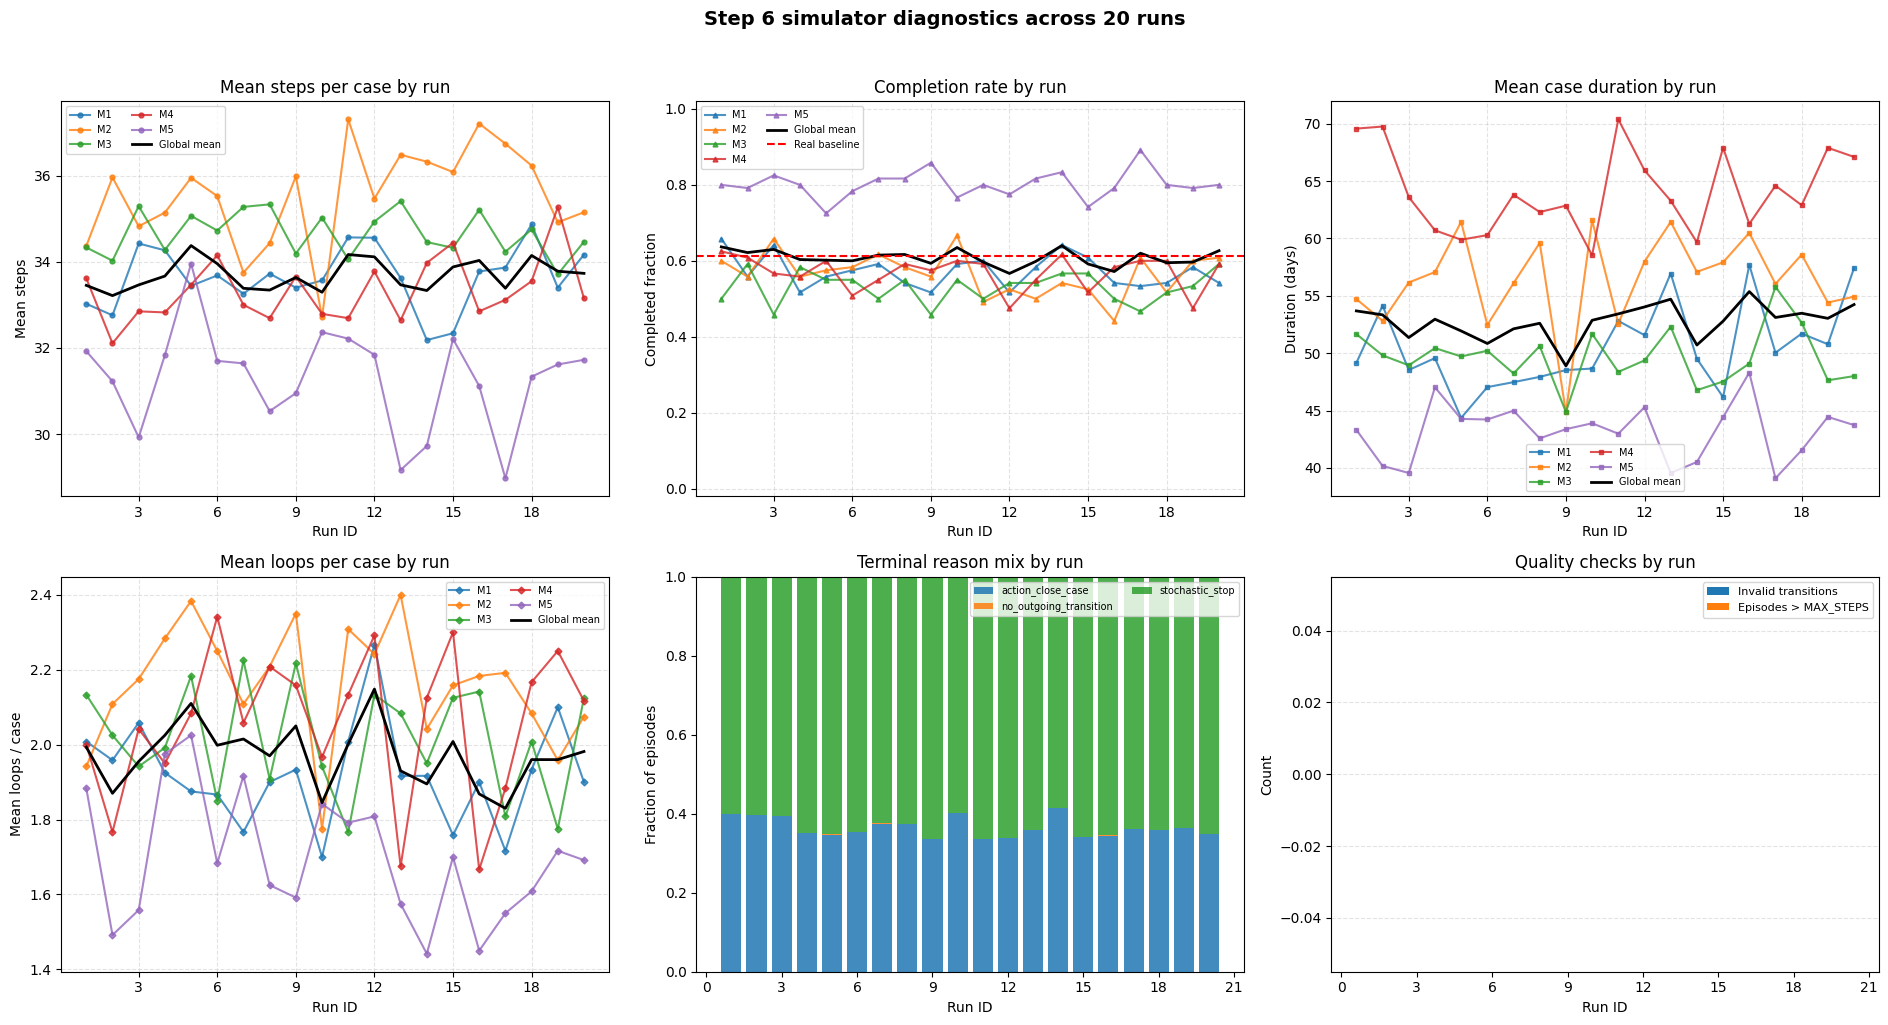


Run-level summary (mean ± std across runs):


,mean,std
mean_steps,33.691583,0.347944
mean_duration_hours,1266.545540,35.966839
completion_rate,0.607833,0.020542
mean_loops,1.970750,0.082720


,run_id,episodes,mean_steps,mean_duration_hours,completion_rate,mean_loops,invalid_transitions,episodes_over_cap
0,1,600,33.453333,1288.351450,0.636667,1.993333,0,0
1,2,600,33.215000,1280.135577,0.621667,1.870000,0,0
2,3,600,33.463333,1232.573361,0.630000,1.955000,0,0
3,4,600,33.668333,1271.031150,0.603333,2.025000,0,0
4,5,600,34.376667,1246.419074,0.601667,2.110000,0,0
5,6,600,33.956667,1220.191261,0.600000,1.998333,0,0
6,7,600,33.385000,1250.831364,0.615000,2.015000,0,0
7,8,600,33.343333,1262.491080,0.616667,1.970000,0,0
8,9,600,33.636667,1173.384852,0.593333,2.050000,0,0
9,10,600,33.293333,1268.738853,0.635000,1.845000,0,0


In [31]:
# ── Multi-run diagnostics dashboard (all 20 runs) ─────────────────────────
import matplotlib.ticker as mticker

if 'run_id' not in sim_episode_df.columns:
    sim_episode_df['run_id'] = 1
if 'run_id' not in sim_trace_df.columns:
    sim_trace_df['run_id'] = 1

sim_episode_df['run_id'] = pd.to_numeric(sim_episode_df['run_id'], errors='coerce').fillna(1).astype(int)
sim_trace_df['run_id'] = pd.to_numeric(sim_trace_df['run_id'], errors='coerce').fillna(1).astype(int)

run_m_summary = (
    sim_episode_df.groupby(['run_id', 'municipality'])
    .agg(
        mean_steps=('steps', 'mean'),
        mean_duration_hours=('duration_hours', 'mean'),
        completion_rate=('case_completed', 'mean'),
        mean_loops=('loops', 'mean'),
        n_cases=('case_id', 'size'),
    )
    .reset_index()
 )

run_summary_df = (
    sim_episode_df.groupby('run_id')
    .agg(
        episodes=('case_id', 'size'),
        mean_steps=('steps', 'mean'),
        mean_duration_hours=('duration_hours', 'mean'),
        completion_rate=('case_completed', 'mean'),
        mean_loops=('loops', 'mean'),
    )
    .reset_index()
    .sort_values('run_id')
)

# Run-level quality checks
transition_rows = sim_trace_df[sim_trace_df['next_activity'].notna()].copy()
invalid_by_run = {}
for run_id, grp in transition_rows.groupby('run_id'):
    invalid = 0
    for _, row in grp.iterrows():
        m = int(row['municipality'])
        edge = (str(row['activity']), str(row['next_activity']))
        if edge not in allowed_edges_by_m.get(m, set()):
            invalid += 1
    invalid_by_run[int(run_id)] = int(invalid)

overcap_by_run = (
    sim_episode_df.assign(over_cap=sim_episode_df['steps'] > MAX_STEPS)
    .groupby('run_id')['over_cap']
    .sum()
    .astype(int)
    .to_dict()
)

run_summary_df['invalid_transitions'] = run_summary_df['run_id'].map(invalid_by_run).fillna(0).astype(int)
run_summary_df['episodes_over_cap'] = run_summary_df['run_id'].map(overcap_by_run).fillna(0).astype(int)

real_completion_rate = float(
    features_df.groupby(['municipality', 'case_id'])['case_completed'].max().astype(float).mean()
)

run_ids = sorted(run_summary_df['run_id'].unique())
municipalities = sorted(run_m_summary['municipality'].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.suptitle(f'Step 6 simulator diagnostics across {len(run_ids)} runs', fontsize=14, fontweight='bold', y=1.02)

# Panel 1: mean steps per run (per municipality + global)
ax = axes[0, 0]
for i, m in enumerate(municipalities):
    sub = run_m_summary[run_m_summary['municipality'] == m].sort_values('run_id')
    ax.plot(sub['run_id'], sub['mean_steps'], marker='o', ms=3.5, color=colors[i % len(colors)], alpha=0.8, label=f'M{m}')
ax.plot(run_summary_df['run_id'], run_summary_df['mean_steps'], color='black', linewidth=2.0, label='Global mean')
ax.set_title('Mean steps per case by run')
ax.set_xlabel('Run ID')
ax.set_ylabel('Mean steps')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(fontsize=7, ncol=2)

# Panel 2: completion rate per run vs real baseline
ax = axes[0, 1]
for i, m in enumerate(municipalities):
    sub = run_m_summary[run_m_summary['municipality'] == m].sort_values('run_id')
    ax.plot(sub['run_id'], sub['completion_rate'], marker='^', ms=3.5, color=colors[i % len(colors)], alpha=0.8, label=f'M{m}')
ax.plot(run_summary_df['run_id'], run_summary_df['completion_rate'], color='black', linewidth=2.0, label='Global mean')
ax.axhline(real_completion_rate, color='red', linestyle='--', linewidth=1.5, label='Real baseline')
ax.set_title('Completion rate by run')
ax.set_xlabel('Run ID')
ax.set_ylabel('Completed fraction')
ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(fontsize=7, ncol=2)

# Panel 3: mean duration (days) per run
ax = axes[0, 2]
for i, m in enumerate(municipalities):
    sub = run_m_summary[run_m_summary['municipality'] == m].sort_values('run_id')
    ax.plot(sub['run_id'], sub['mean_duration_hours'] / 24.0, marker='s', ms=3.5, color=colors[i % len(colors)], alpha=0.8, label=f'M{m}')
ax.plot(run_summary_df['run_id'], run_summary_df['mean_duration_hours'] / 24.0, color='black', linewidth=2.0, label='Global mean')
ax.set_title('Mean case duration by run')
ax.set_xlabel('Run ID')
ax.set_ylabel('Duration (days)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(fontsize=7, ncol=2)

# Panel 4: mean loops by run
ax = axes[1, 0]
for i, m in enumerate(municipalities):
    sub = run_m_summary[run_m_summary['municipality'] == m].sort_values('run_id')
    ax.plot(sub['run_id'], sub['mean_loops'], marker='D', ms=3.5, color=colors[i % len(colors)], alpha=0.8, label=f'M{m}')
ax.plot(run_summary_df['run_id'], run_summary_df['mean_loops'], color='black', linewidth=2.0, label='Global mean')
ax.set_title('Mean loops per case by run')
ax.set_xlabel('Run ID')
ax.set_ylabel('Mean loops / case')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(fontsize=7, ncol=2)

# Panel 5: terminal reason composition by run (stacked)
ax = axes[1, 1]
if 'terminal_reason' in sim_episode_df.columns:
    term = (
        sim_episode_df.groupby(['run_id', 'terminal_reason'])
        .size()
        .reset_index(name='count')
    )
    total = term.groupby('run_id')['count'].transform('sum')
    term['fraction'] = term['count'] / total

    top_reasons = (
        term.groupby('terminal_reason')['count'].sum().sort_values(ascending=False).head(5).index.tolist()
    )
    term['terminal_reason_plot'] = np.where(term['terminal_reason'].isin(top_reasons), term['terminal_reason'], 'other')
    term_plot = (
        term.groupby(['run_id', 'terminal_reason_plot'])['fraction']
        .sum()
        .unstack(fill_value=0.0)
        .sort_index()
    )

    bottom = np.zeros(len(term_plot))
    for i, reason in enumerate(term_plot.columns):
        vals = term_plot[reason].values
        ax.bar(term_plot.index, vals, bottom=bottom, label=reason, alpha=0.85)
        bottom += vals

    ax.set_ylim(0, 1.0)
    ax.set_title('Terminal reason mix by run')
    ax.set_xlabel('Run ID')
    ax.set_ylabel('Fraction of episodes')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=7, ncol=2)
else:
    ax.set_visible(False)

# Panel 6: run quality checks
ax = axes[1, 2]
x = run_summary_df['run_id'].values
w = 0.40
ax.bar(x - w/2, run_summary_df['invalid_transitions'].values, width=w, label='Invalid transitions')
ax.bar(x + w/2, run_summary_df['episodes_over_cap'].values, width=w, label='Episodes > MAX_STEPS')
ax.set_title('Quality checks by run')
ax.set_xlabel('Run ID')
ax.set_ylabel('Count')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nRun-level summary (mean ± std across runs):')
summary_stats = run_summary_df[['mean_steps', 'mean_duration_hours', 'completion_rate', 'mean_loops']].agg(['mean', 'std']).T
display(summary_stats)
display(run_summary_df.head(20))

## Step 6 complete

You now have a calibrated SimPy simulation with action hook and logged outputs:
- `./output/sim_trace_table.csv`
- `./output/sim_episode_summary.csv`

Next step: validate simulator against real logs (Step 7).